In [5]:
from borough_complaints import query

df_jan_feb = query("../.in/311_Service_Requests_2024.csv", "2024-01-01", "2024-03-01")
df_jan_feb.head(10)

,complaint type,borough,count
0,AHV Inspection Unit,BRONX,1
1,AHV Inspection Unit,BROOKLYN,3
2,AHV Inspection Unit,MANHATTAN,8
3,APPLIANCE,BRONX,1376
4,APPLIANCE,BROOKLYN,1132
5,APPLIANCE,MANHATTAN,710
6,APPLIANCE,QUEENS,482
7,APPLIANCE,STATEN ISLAND,85
8,Abandoned Bike,BRONX,9
9,Abandoned Bike,BROOKLYN,175


In [6]:
total_by_complaint = df_jan_feb.groupby('complaint type')['count'].sum().reset_index()
total_by_complaint = total_by_complaint.sort_values('count', ascending=False)
total_by_complaint.head(10)

,complaint type,count
70,HEAT/HOT WATER,82671
82,Illegal Parking,81354
109,Noise - Residential,44378
14,Blocked Driveway,29073
163,UNSANITARY CONDITION,19496
120,PLUMBING,12259
119,PAINT/PLASTER,11906
3,Abandoned Vehicle,11682
150,Street Condition,11083
172,WATER LEAK,9295


In [7]:
most_abundant = total_by_complaint.loc[total_by_complaint['count'].idxmax(), 'complaint type']
most_abundant

'HEAT/HOT WATER'

In [8]:
df_jan_feb_abundant = df_jan_feb[df_jan_feb['complaint type'] == most_abundant]
df_jan_feb_abundant.head(10)

,complaint type,borough,count
300,HEAT/HOT WATER,BRONX,30519
301,HEAT/HOT WATER,BROOKLYN,21168
302,HEAT/HOT WATER,MANHATTAN,17838
303,HEAT/HOT WATER,QUEENS,12270
304,HEAT/HOT WATER,STATEN ISLAND,876


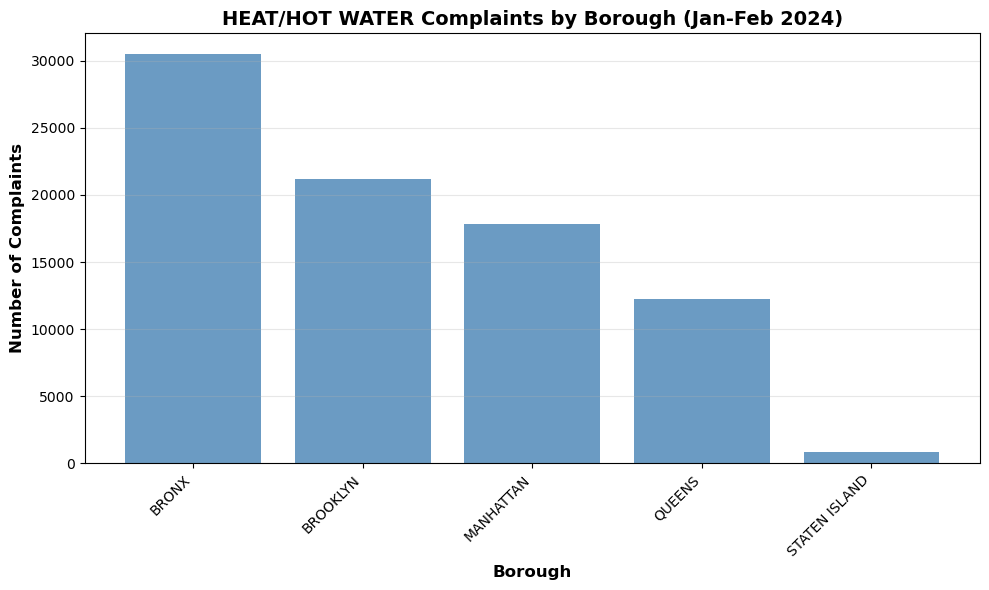

In [9]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(df_jan_feb_abundant['borough'], df_jan_feb_abundant['count'], color='steelblue', alpha=0.8)
ax.set_xlabel('Borough', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Complaints', fontsize=12, fontweight='bold')
ax.set_title(f'{most_abundant} Complaints by Borough (Jan-Feb 2024)', 
             fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

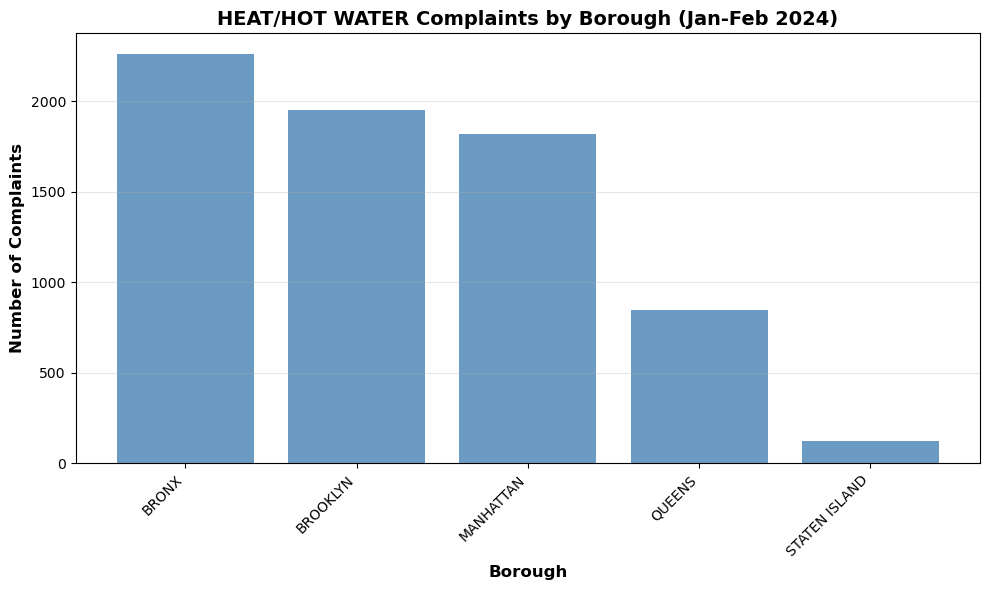

In [11]:
df_jun_jul = query("../.in/311_Service_Requests_2024.csv", "2024-06-01", "2024-08-01")
df_jun_jul_abundant = df_jun_jul[df_jun_jul['complaint type'] == most_abundant]

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(df_jun_jul_abundant['borough'], df_jun_jul_abundant['count'], color='steelblue', alpha=0.8)
ax.set_xlabel('Borough', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Complaints', fontsize=12, fontweight='bold')
ax.set_title(f'{most_abundant} Complaints by Borough (Jan-Feb 2024)', 
             fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [12]:
total_jan_feb = df_jan_feb_abundant['count'].sum()
total_june_july = df_jun_jul_abundant['count'].sum()
percent_change = ((total_june_july - total_jan_feb) / total_jan_feb) * 100

print(f"\n{'='*60}")
print(f"COMPARISON: {most_abundant} Complaints")
print(f"{'='*60}")
print(f"Jan-Feb 2024: {total_jan_feb:,} complaints")
print(f"June-July 2024: {total_june_july:,} complaints")
print(f"Difference: {total_june_july - total_jan_feb:+,} complaints")
print(f"Percent change: {percent_change:+.1f}%")
print(f"{'='*60}")


COMPARISON: HEAT/HOT WATER Complaints
Jan-Feb 2024: 82,671 complaints
June-July 2024: 7,006 complaints
Difference: -75,665 complaints
Percent change: -91.5%


In [14]:
import pandas as pd

print(f"\nBorough-level comparison:")
comparison_df = pd.merge(
    df_jan_feb_abundant[['borough', 'count']].rename(columns={'count': 'Jan-Feb'}),
    df_jun_jul_abundant[['borough', 'count']].rename(columns={'count': 'June-July'}),
    on='borough',
    how='outer'
).fillna(0)
comparison_df['Difference'] = comparison_df['June-July'] - comparison_df['Jan-Feb']
comparison_df['% Change'] = (comparison_df['Difference'] / comparison_df['Jan-Feb'] * 100).round(1)
print(comparison_df.to_string(index=False))


Borough-level comparison:
      borough  Jan-Feb  June-July  Difference  % Change
        BRONX    30519       2263      -28256     -92.6
     BROOKLYN    21168       1953      -19215     -90.8
    MANHATTAN    17838       1820      -16018     -89.8
       QUEENS    12270        846      -11424     -93.1
STATEN ISLAND      876        124        -752     -85.8
